# 周期定常の考え方を用いて、自然室温を計算する

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import response_factor as rf

In [78]:
# 気象データの読み込み
# CSVを読み込み（Shift_JISやCP932など必要に応じて変更）
df = pd.read_csv('weather_data/tokyo.csv', header=None, encoding='ansi')

# 最初の列を項目名、残りを時刻データとして扱う
df_weather = df.set_index(0).T

# 時刻列のインデックス名を付ける（任意）
df_weather.index = [f"i" for i in range(df_weather.shape[0])]

# 風向を削除
df_weather.drop(columns=['風向'], inplace=True)

# すべてのデータをfloat型に変換
df_weather = df_weather.astype(float)

# 外気温度
T_o = df_weather['乾球温度[℃]'].to_numpy()

# 夜間放射量
rn = df_weather['夜間放射量[W/㎡]'].to_numpy()

# 太陽高度
h = np.radians(df_weather['太陽高度[゜]'].to_numpy())
# 太陽方位角
az = np.radians(df_weather['太陽方位角[゜]'].to_numpy())

# 直達日射量
I_d = df_weather['直達日射量[W/㎡]'].to_numpy()
# 天空日射量
I_s = df_weather['天空日射量[W/㎡]'].to_numpy()
# 水平面全天日射量
I_global = I_d * np.sin(h) + I_s
# 地物反射日射量
albedo = 0.1
I_g = I_global * albedo

# 結果を表示（または使いたい形式で処理）
df_weather

,乾球温度[℃],絶対湿度[g/kg],エンタルピ[J/g],夜間放射量[W/㎡],風速[m/s],太陽高度[゜],太陽方位角[゜],直達日射量[W/㎡],天空日射量[W/㎡]
i,28.1,19.9,79.0,47.0,2.3,0.0,0.0,0.0,0.0
i,27.8,19.9,78.7,46.0,2.1,0.0,0.0,0.0,0.0
i,27.5,19.8,78.2,44.0,2.1,0.0,0.0,0.0,0.0
i,27.3,19.7,77.7,43.0,1.8,0.0,0.0,0.0,0.0
i,27.1,19.7,77.5,42.0,1.9,1.3,-111.4,0.0,3.0
i,27.7,20.0,78.8,44.0,1.7,12.9,-103.1,227.0,61.0
i,28.9,20.2,80.7,46.0,1.8,24.9,-95.0,387.0,117.0
i,30.4,20.1,82.0,50.0,1.7,37.1,-86.2,436.0,173.0
i,31.7,19.8,82.5,53.0,2.0,49.1,-75.7,466.0,217.0
i,33.1,19.9,84.3,55.0,2.0,60.4,-60.4,498.0,260.0


In [79]:
# 内部発熱
H_n = np.array([50.0] * 24)

In [80]:
# 各種パラメータの計算

# 空気の比熱[J/(kg･K)]
c_a = 1005.0
# 空気の密度[kg/m^3]
rho_a = 1.2
# 空気の比熱と密度の積[J/(m^3･K)]
c_rho_a = c_a * rho_a
# 時間刻み[s]
delta_t = 3600.0
# 外表面の日射吸収率[－]
a_s = 0.8
# 外表面の放射率[－]
eps_s = 0.9
# 外表面の熱伝達抵抗[㎡･K/W]
R_so = 0.04
# 内表面の熱伝達抵抗[㎡･K/W]
R_si = 0.11

In [81]:
# 建物モデル
area = np.array([25.0, 25.0, 10.0, 10.0, 20.0, 20.0, 20.0])  # 各面の面積 [m^2]
n_s = len(area)  # 面の数
# 各面の方位角
azimuth = np.radians(np.array([0, 0, 0, 0, 90, 180, -90]))  # 各面の方位角 [rad]
# 各面の傾斜角
tilt = np.radians(np.array([0, 180, 90, 90, 90, 90, 90]))  # 各面の傾斜角 [rad]
# 部位の日射熱取得率
eta_s = np.array([0.0, 0.0, 0.8, 0.0, 0.0, 0.0, 0.0])  # 各面の日射熱取得率 [－]

# 室の気積[m^3]
Vol = 5.0 * 5.0 * 4.0

# 換気量[m^3/s]
Vi = Vol * 0.5 / 3600.0
Vi_24 = np.array([Vi] * 24)

# 家具の熱容量を考慮して室気積を10倍にする
Vol *= 10.0

In [82]:
# 壁体構成
rs = np.array([
    R_si,
    0.05 / 0.023,
    0.12 / 1.6,
    R_so
])
cs = np.array([
    0.0,
    0.05 * 60 * 1000.0,
    2000.0 * 0.12 * 1000.0,
    0.0
])

In [83]:
# 応答係数用パラメータの計算
a0, aa, at, alpha = rf.calc_alpha_matsuo_method(rs=rs, cs=cs, i_max=15)

In [84]:
# 周期定常応答係数の計算
cyclic_phi_t = rf.calc_cyclic_response_factor(at=at, alpha=alpha, a0=a0, delta_t=3600)
cyclic_phi_a = rf.calc_cyclic_response_factor(at=aa, alpha=alpha, a0=a0, delta_t=3600)

# 放熱応答係数の計算
cyclic_phi_d = - cyclic_phi_a * R_si
cyclic_phi_d[0] = 1.0 - cyclic_phi_a[0] * R_si

### 応急措置として全部位で同じ応答係数を使用する。将来的に要変更

In [85]:
# 24要素 → (n_s, 24) に複製
phiT = np.broadcast_to(cyclic_phi_t, (n_s, cyclic_phi_t.size)).copy()  # φ_T,k,j*
phiA = np.broadcast_to(cyclic_phi_a, (n_s, cyclic_phi_a.size)).copy()  # φ_A,k,j*
phiD = np.broadcast_to(cyclic_phi_d, (n_s, cyclic_phi_d.size)).copy()  # φ_D,k,j*

In [86]:
# 各面の天空に対する形態係数
F_sky = (1.0 - np.cos(tilt)) / 2.0
# 各面の地物に対する形態係数
F_g = 1.0 - F_sky

# 各面の入射角の方向余弦の計算
cos_i = np.sin(h)[:, np.newaxis] * np.cos(tilt)[np.newaxis, :] \
        + np.cos(h)[:, np.newaxis] * np.sin(tilt)[np.newaxis, :] * np.cos(az[:, np.newaxis] - azimuth[np.newaxis, :])
cos_i[cos_i < 0] = 0.0  # 負の値は0にする
print(cos_i)

[[0.00000000e+00 1.22464680e-16 1.00000000e+00 1.00000000e+00
  6.12323400e-17 0.00000000e+00 6.12323400e-17]
 [0.00000000e+00 1.22464680e-16 1.00000000e+00 1.00000000e+00
  6.12323400e-17 0.00000000e+00 6.12323400e-17]
 [0.00000000e+00 1.22464680e-16 1.00000000e+00 1.00000000e+00
  6.12323400e-17 0.00000000e+00 6.12323400e-17]
 [0.00000000e+00 1.22464680e-16 1.00000000e+00 1.00000000e+00
  6.12323400e-17 0.00000000e+00 6.12323400e-17]
 [2.26873336e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 3.64782868e-01 9.30816171e-01]
 [2.23250116e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 2.20930899e-01 9.49393977e-01]
 [4.21035813e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 7.90540948e-02 9.03592438e-01]
 [6.03207988e-01 0.00000000e+00 5.28589979e-02 5.28589979e-02
  0.00000000e+00 0.00000000e+00 7.95830415e-01]
 [7.55853469e-01 0.00000000e+00 1.61720335e-01 1.61720335e-01
  0.00000000e+00 0.00000000e+00 6.34454148e-01]
 [8.694949

In [87]:
# 傾斜面直達日射量の計算
I_d_tilted = I_d[:, np.newaxis] * cos_i

# 傾斜面天空日射量の計算
I_s_tilted = I_s[:, np.newaxis] * F_sky[np.newaxis, :]

# 傾斜面地物反射日射量の計算
I_g_tilted = I_g[:, np.newaxis] * F_g[np.newaxis, :]

print("傾斜面直達日射量 (I_d_tilted):", I_d_tilted)
print("傾斜面天空日射量 (I_s_tilted):", I_s_tilted)
print("傾斜面地物反射日射量 (I_g_tilted):", I_g_tilted)

傾斜面直達日射量 (I_d_tilted): [[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.06777763e+01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 5.01513141e+01 2.15512433e+02]
 [1.62940860e+02 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 3.05939347e+01 3.49690273e+02]
 [2.62998683e+02 0.00000000e+00 2.30465231e+01 2.30465231e+01
  0.00000000e+00 0.00000000e+00 3.46982061e+02]
 [3.52227717e+02 0.00000000e+00 7.53616759e+01 7.53616759e+01
  0.00000000e+00 0.00000000e+00 2.9

In [88]:
# 各面の相当外気温度の計算
T_eo = T_o[:, np.newaxis] + (a_s * (I_d_tilted + I_s_tilted + I_g_tilted) - eps_s * rn[:, np.newaxis] * F_sky[np.newaxis, :]) * R_so
print("各面の相当外気温度 (T_eq):", T_eo)
print(F_g)

各面の相当外気温度 (T_eq): [[28.1        26.408      27.254      27.254      27.254      27.254
  27.254     ]
 [27.8        26.144      26.972      26.972      26.972      26.972
  26.972     ]
 [27.5        25.916      26.708      26.708      26.708      26.708
  26.708     ]
 [27.3        25.752      26.526      26.526      26.526      26.526
  26.526     ]
 [27.1096     25.684      26.3968     26.3968     26.3968     26.3968
  26.3968    ]
 [29.67905773 28.068      28.06268444 28.06268444 28.06268444 29.66752649
  34.95908229]
 [35.00991826 30.988      30.39190538 30.39190538 30.39190538 31.37091129
  41.58199413]
 [40.21115363 34.136      33.70308663 33.70308663 32.96559789 32.96559789
  44.06902385]
 [44.79281563 36.736      37.54033798 37.54033798 35.12876435 35.12876435
  44.58974461]
 [49.17389832 39.44       41.26685601 41.26685601 37.37881356 37.37881356
  44.22300602]
 [51.39314311 41.044      43.36444172 43.36444172 38.68023378 38.68023378
  41.81603768]
 [52.15314212 41.696      4

In [89]:
# 透過日射の計算
q_sol_total = (np.sum(area * eta_s * (I_d_tilted + I_s_tilted + I_g_tilted), axis=1) / np.sum(area)).flatten()
q_sol = np.broadcast_to(q_sol_total[:, None], (24, n_s)).copy()  # q_sol,k,j*
print(np.sum(area))
print(np.sum(area * eta_s * (I_d_tilted + I_s_tilted + I_g_tilted), axis=1))

130.0
[   0.            0.            0.            0.           13.2
  288.67111053  579.97634391 1050.7716576  1698.58449396 2289.21400314
 2609.11042936 2705.02349046 2528.32755563 2062.74122322 1462.38400302
  793.2951202   423.91919055  158.61813675    0.            0.
    0.            0.            0.            0.        ]


In [90]:
M = np.zeros((24, 24), dtype=float)
b = np.zeros(24, dtype=float)

In [91]:
# ====== 応答係数：部位ごとに (n_s, 24) へ展開 ======
n_s = area.size

phiT = np.broadcast_to(cyclic_phi_t, (n_s, 24)).copy()  # φ_T,k,j^*
phiA = np.broadcast_to(cyclic_phi_a, (n_s, 24)).copy()  # φ_A,k,j^*
# φ_D は部位により R_si が違ってもOK（同じなら R_si をスカラーで）
R_si_k = np.full(n_s, R_si)                              # 例：全て同じ
phiD = phiA * R_si_k[:, None]
phiD[:, 0] = 1.0 - phiA[:, 0] * R_si_k

# ====== 拡張式に対応した M, b の組み立て（for なし） ======
N   = 24
idx = (np.arange(N)[:, None] - np.arange(N)[None, :]) % N
P   = np.roll(np.eye(N), -1, axis=1)                      # (T_{r,n-1}) 用シフト行列

# 各部位の循環行列（k, i, j）
C_phiA = phiA[:, idx]
C_phiT = phiT[:, idx]
C_phiD = phiD[:, idx]

# --- 係数（部位ごと）。必要に応じて設定 ---
# 外壁：k_r=0, k_eo=1, k_o=0 / 内壁：k_eo=0, k_o=0, 必要に応じて k_r>0
k_r  = np.zeros(n_s)     # 室内側（内壁）結合係数
k_eo = np.ones(n_s)      # 相当外気温への結合係数
k_o  = np.zeros(n_s)     # 外気温 To,n への結合係数

# 室内側総合熱伝達率 h_i
h_i = np.full(n_s, 1.0 / R_si)

# --- 係数行列 M ---
M = (
    np.diag(c_rho_a * (Vol / delta_t + Vi_24))              # 対角
    - (c_rho_a * (Vol / delta_t)) * P                       # n-1 項
    + np.tensordot(area,     C_phiA, axes=(0, 0))           #  + Σ A_k C_phiA(k)
    - np.tensordot(area*k_r, C_phiT, axes=(0, 0))           #  − Σ A_k k_r,k C_phiT(k)
)

# --- 右辺 b ---
# 各部位の温度入力 x_k = k_eo,k * T_eo[:,k] + k_o,k * T_o[:]
X_T = k_eo[None, :] * T_eo + k_o[None, :] * T_o[:, None]     # (24, n_s)

rhs_shell = (
    np.einsum('kij,jk,k->i', C_phiT, X_T,             area)  #  Σ A_k C_phiT(k) @ x_k
  + np.einsum('kij,jk,k->i', C_phiD, q_sol,           area)  #  Σ A_k C_phiD(k) @ q_sol_k
  - np.einsum('kij,jk,k->i', C_phiA, q_sol/h_i[None,:],area)  # −Σ A_k C_phiA(k) @ (q_sol_k/h_i,k)
)
rhs_vent = c_rho_a * Vi_24 * T_o

b = rhs_shell + rhs_vent + H_n

# （必要なら微小正則化）
# M += 1e-12*np.eye(N)

# 解く
T_r = np.linalg.solve(M, b)


In [92]:
print(T_r)
print(T_o)

[37.98291998 36.77999792 35.68025155 34.6798679  33.79684115 33.56077285
 33.97087937 35.36072148 37.97042637 41.53657902 45.38371021 49.01969976
 51.92522792 53.62694342 54.02203595 53.0992933  51.58832632 49.71315428
 47.66407367 45.75255939 43.95413483 42.2794178  40.72836677 39.29652016]
[28.1 27.8 27.5 27.3 27.1 27.7 28.9 30.4 31.7 33.1 33.9 34.3 34.6 34.7
 34.7 33.6 32.6 31.7 30.6 30.  29.4 29.1 28.8 28.4]


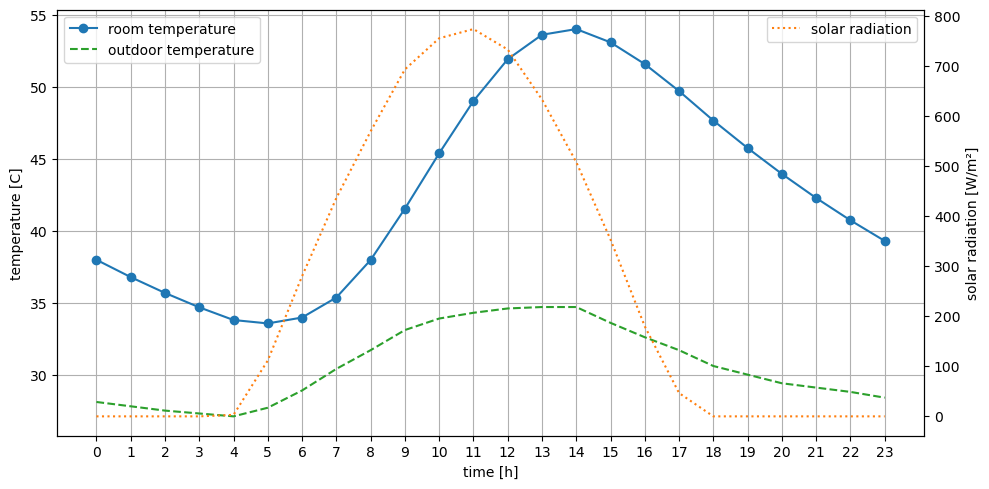

In [93]:
# === プロット ===
fig, ax1 = plt.subplots(figsize=(10, 5))

# 室温と外気温（第1軸）
ax1.plot(T_r, label="room temperature", marker='o', color='tab:blue')
ax1.plot(T_o, label="outdoor temperature", linestyle='--', color='tab:green')
ax1.set_xlabel("time [h]")
ax1.set_ylabel("temperature [C]")
ax1.set_xticks(range(0, 24, 1))
ax1.grid(True)
ax1.legend(loc="upper left")

# 日射量（第2軸）
ax2 = ax1.twinx()
ax2.plot(I_global, label="solar radiation", linestyle=':', color='tab:orange')
ax2.set_ylabel("solar radiation [W/m²]")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()